# 05. Matrix Factorization (ALS) vs Popularity Baseline

02~03번에서 만든 **Popularity baseline**은 모든 유저에게 동일한 Top-N을 추천합니다.  
이번에는 **ALS(Alternating Least Squares)** 행렬분해로 유저별 개인화 추천을 만들고,  
둘의 예측 성능을 비교합니다.

| 모델 | 개인화 | 입력 |
|---|---|---|
| Popularity | X (전체 동일) | repo별 가중 점수 |
| ALS | O (유저별) | user×item sparse matrix |

## 1. 데이터 준비 & Train/Test Split

In [1]:
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import sparse

from ghrec.recommend import load_period, popularity_scores, top_n_repos

OUTPUT_DIR = Path("../../data/daily_agg")

TRAIN_START, TRAIN_END = date(2026, 3, 1), date(2026, 3, 6)
TEST_START, TEST_END = date(2026, 3, 7), date(2026, 3, 7)

WEIGHTS = {
    "WatchEvent": 1.0,
    "ForkEvent": 2.0,
    "IssuesEvent": 0.5,
    "PullRequestEvent": 3.0,
    "IssueCommentEvent": 0.3,
    "PushEvent": 0.2,
}

train_df = load_period(OUTPUT_DIR, TRAIN_START, TRAIN_END)
test_df = load_period(OUTPUT_DIR, TEST_START, TEST_END)

print(f"Train (raw): {len(train_df):,} rows")
print(f"Test (raw):  {len(test_df):,} rows")

# --- 유저 샘플링 ---
SAMPLE_RATIO = 0.30

rng = np.random.default_rng(42)
all_users = set(train_df["actor_id"].unique()) | set(test_df["actor_id"].unique())
sampled_users = set(rng.choice(list(all_users), size=int(len(all_users) * SAMPLE_RATIO), replace=False))

train_df = train_df[train_df["actor_id"].isin(sampled_users)]
test_df = test_df[test_df["actor_id"].isin(sampled_users)]

print(f"\nSampled {SAMPLE_RATIO:.0%} users: {len(sampled_users):,}")
print(f"Train: {len(train_df):,} rows  ({TRAIN_START} ~ {TRAIN_END})")
print(f"Test:  {len(test_df):,} rows  ({TEST_START} ~ {TEST_END})")

Train (raw): 8,685,074 rows
Test (raw):  1,290,012 rows



Sampled 30% users: 783,833
Train: 3,396,640 rows  (2026-03-01 ~ 2026-03-06)
Test:  491,595 rows  (2026-03-07 ~ 2026-03-07)


In [2]:
def build_feedback(df, weights):
    """이벤트 가중치 적용 → (actor_id, repo_id, score) 집계."""
    df = df.copy()
    df["score"] = df["type"].map(weights).fillna(0) * df["cnt"]
    fb = df.groupby(["actor_id", "repo_id"])["score"].sum().reset_index()
    return fb[fb["score"] > 0]

train_fb = build_feedback(train_df, WEIGHTS)
test_fb = build_feedback(test_df, WEIGHTS)

print(f"Train feedback: {len(train_fb):,} (유저 {train_fb["actor_id"].nunique():,}, 레포 {train_fb["repo_id"].nunique():,})")
print(f"Test feedback:  {len(test_fb):,} (유저 {test_fb["actor_id"].nunique():,}, 레포 {test_fb["repo_id"].nunique():,})")

Train feedback: 1,360,109 (유저 629,519, 레포 1,154,897)
Test feedback:  362,900 (유저 167,781, 레포 332,434)


## 2. 평가 대상 유저

**Train ∩ Test 유저**만 평가합니다.  
교집합에 없는 유저는 어차피 popularity fallback이므로 평가에 반영할 필요 없습니다.

In [3]:
test_users_all = set(test_fb["actor_id"])
train_users_all = set(train_fb["actor_id"])
eval_users = sorted(test_users_all & train_users_all)

print(f"전체 Test 유저:     {len(test_users_all):,}")
print(f"전체 Train 유저:    {len(train_users_all):,}")
print(f"Train ∩ Test 유저:  {len(eval_users):,}  (평가 대상)")
print(f"Test only 유저:     {len(test_users_all - train_users_all):,}  (cold start → pop fallback)")

전체 Test 유저:     167,781
전체 Train 유저:    629,519
Train ∩ Test 유저:  104,899  (평가 대상)
Test only 유저:     62,882  (cold start → pop fallback)


## 3. Sparse Matrix 구축

ALS 학습에 필요한 user×item sparse matrix를 만듭니다.

In [4]:
all_user_ids = train_fb["actor_id"].unique()
all_item_ids = train_fb["repo_id"].unique()

user2idx = {uid: i for i, uid in enumerate(all_user_ids)}
item2idx = {iid: i for i, iid in enumerate(all_item_ids)}
idx2item = {i: iid for iid, i in item2idx.items()}

row = train_fb["actor_id"].map(user2idx).values
col = train_fb["repo_id"].map(item2idx).values
data = train_fb["score"].values.astype(np.float32)

train_sparse = sparse.csr_matrix(
    (data, (row, col)),
    shape=(len(all_user_ids), len(all_item_ids)),
)

print(f"Sparse matrix: {train_sparse.shape[0]:,} users × {train_sparse.shape[1]:,} items")
print(f"Non-zero: {train_sparse.nnz:,}")
print(f"Sparsity: {1 - train_sparse.nnz / (train_sparse.shape[0] * train_sparse.shape[1]):.6%}")

Sparse matrix: 629,519 users × 1,154,897 items
Non-zero: 1,360,109
Sparsity: 99.999813%


## 4. ALS 학습

In [5]:
from implicit.als import AlternatingLeastSquares

model = AlternatingLeastSquares(
    factors=64,
    regularization=0.01,
    iterations=15,
    random_state=42,
)

model.fit(train_sparse)
print(f"ALS 학습 완료 — factors={model.factors}, iterations={model.iterations}")

/Users/kakao/bda-2/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  0%|          | 0/15 [00:00<?, ?it/s]

  7%|▋         | 1/15 [00:04<00:58,  4.16s/it]

 13%|█▎        | 2/15 [00:07<00:48,  3.74s/it]

 20%|██        | 3/15 [00:10<00:39,  3.32s/it]

...

 87%|████████▋ | 13/15 [00:43<00:06,  3.03s/it]

 93%|█████████▎| 14/15 [00:46<00:02,  2.91s/it]

100%|██████████| 15/15 [00:53<00:00,  4.09s/it]

100%|██████████| 15/15 [00:53<00:00,  3.54s/it]

ALS 학습 완료 — factors=64, iterations=15


## 5. Inference & 평가

 모듈로 추천 + 멀티프로세싱 평가를 수행합니다.

In [6]:
import os
import time

from ghrec.inference import evaluate_parallel, recommend_als, recommend_popularity

K_VALUES = [50, 100]
MAX_K = max(K_VALUES)
N_WORKERS = os.cpu_count()

train_scores = popularity_scores(train_df, WEIGHTS)
pop_candidates = train_scores.head(MAX_K + 500).index.tolist()

test_gt = test_fb.groupby("actor_id")["repo_id"].apply(set).to_dict()
train_seen = train_fb.groupby("actor_id")["repo_id"].apply(set).to_dict()

t0 = time.time()
pop_recs = recommend_popularity(pop_candidates, train_seen, eval_users, MAX_K)
t_pop = time.time() - t0

t0 = time.time()
als_recs = recommend_als(model, train_sparse, user2idx, idx2item, eval_users, MAX_K)
t_als = time.time() - t0

print(f"Popularity 추천: {t_pop:.1f}s")
print(f"ALS 추천:        {t_als:.1f}s")
print(f"평가 유저:       {len(eval_users):,}")

t0 = time.time()
eval_results = evaluate_parallel(pop_recs, als_recs, test_gt, K_VALUES, n_workers=N_WORKERS)
t_eval = time.time() - t0
print(f"평가 ({N_WORKERS} workers): {t_eval:.1f}s")

results_df = pd.DataFrame(eval_results)
print(f"\n{"Metric":<16} {"Popularity":>12} {"ALS":>12}")
print(f"{"─" * 40}")
for k in K_VALUES:
    print(f"\n  K={k}")
    for m in ["precision", "recall", "ndcg"]:
        pop_v = results_df[f"pop_{m}@{k}"].mean()
        als_v = results_df[f"als_{m}@{k}"].mean()
        print(f"  {m:<14} {pop_v:>12.4f} {als_v:>12.4f}")

Popularity 추천: 3.4s
ALS 추천:        153.0s
평가 유저:       104,899


평가 (8 workers): 15.9s



Metric             Popularity          ALS
────────────────────────────────────────

  K=50
  precision            0.0000       0.0001
  recall               0.0017       0.0017
  ndcg                 0.0006       0.0008

  K=100
  precision            0.0000       0.0000
  recall               0.0024       0.0020
  ndcg                 0.0007       0.0008


## 6. 시각화

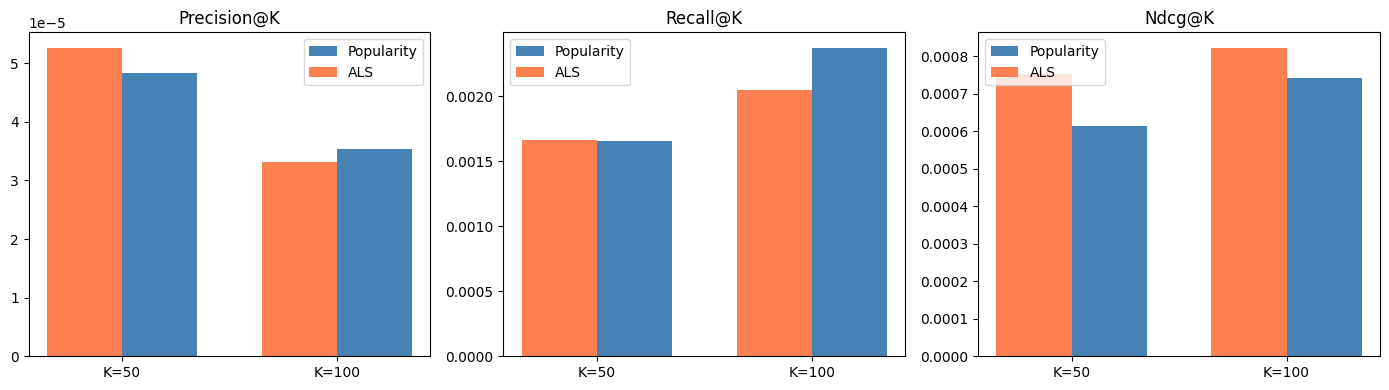

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, metric in zip(axes, ["precision", "recall", "ndcg"]):
    pop_vals = [results_df[f"pop_{metric}@{k}"].mean() for k in K_VALUES]
    als_vals = [results_df[f"als_{metric}@{k}"].mean() for k in K_VALUES]
    ax.bar([f"K={k}" for k in K_VALUES], pop_vals, width=0.35, label="Popularity", color="steelblue", align="edge")
    ax.bar([f"K={k}" for k in K_VALUES], als_vals, width=-0.35, label="ALS", color="coral", align="edge")
    ax.set_title(f"{metric.title()}@K")
    ax.legend()

plt.tight_layout()
plt.show()

## 7. 개인화 효과: 추천 다양성 비교

In [8]:
k = K_VALUES[0]
pop_all = set()
als_all = set()
for uid in eval_users:
    pop_all.update(pop_recs[uid][:k])
    als_all.update(als_recs[uid][:k])

print(f"K={k}, 평가 유저 {len(eval_users):,}명에게 추천된 고유 아이템 수:")
print(f"  Popularity: {len(pop_all):,}")
print(f"  ALS:        {len(als_all):,}")
print(f"  → ALS가 {len(als_all) / max(len(pop_all), 1):.1f}배 더 다양한 아이템 추천")

K=50, 평가 유저 104,899명에게 추천된 고유 아이템 수:
  Popularity: 69
  ALS:        4,700
  → ALS가 68.1배 더 다양한 아이템 추천


## 8. 정리

| | Popularity | ALS |
|---|---|---|
| 개인화 | X | O |
| 학습 필요 | X | O |
| 추천 다양성 | 낮음 | 높음 |
| Cold start 유저 | 동일 추천 | fallback 필요 |

**다음 단계:**
- ALS 하이퍼파라미터 튜닝 (factors, regularization, iterations)
- BPR 등 다른 행렬분해 모델과 비교
- repo 메타데이터를 side information으로 활용